# 15A — Thermodynamics (Bragg–Williams Approximation)

Computes finite-temperature sublattice occupancies using the Bragg–Williams approximation applied to ML formation energies. Produces the R-phase comparison with XRD data.

## Prerequisites / Input files
- `Fe-Mo/Atomsobjects/R_structures.pkl` (available on Zenodo)
- `Fe-Mo/FullyCuratedParsedBriefSummary.pkl`
- `Fe-Mo/results/PREDICTION__R__*.csv`

## Outputs
- Thermodynamics figures in `Fe-Mo/graphs/`



In [1]:
import pandas as pd
from pycef.cef_minimization import *
import json
import os

In [2]:
import re

In [3]:
from matplotlib.lines import Line2D

In [4]:
from Tools.DatasetTools.GeneralFeaturizer import cn_dict

/home/mariano/.local/micromamba/envs/Test_MLFeMoTCPs/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
system = 'Fe-Mo'

In [6]:
lattice_names = {
    'R' : ['$b$', '$c_1$', '$f_1$', '$f_2$', '$f_3$', '$f_4$', '$f_5$', '$f_6$', '$f_7$', '$c_2$', '$f_8$'],
#    'R_10' : ['$b$', '$c_1$', '$f_1$', '$f_2$', '$f_3$', '$f_4$', '$f_5$', '$f_6$', '$f_7$', '$c_2$ and $f_8$'],
#    'delta': ['$a_1$', '$a_2$', '$a_3$', '$a_4$', '$a_5$', '$a_6$', '$a_7$', '$a_8$', '$a_9$', '$a_{10}$', '$a_{11}$', '$a_{12}$', '$a_{13}$', '$a_{14}$'],
    'P': ['$c_1$', '$c_2$', '$c_3$', '$c_4$', '$c_5$', '$c_6$', '$c_7$', '$c_8$', '$c_9$', '$c_{10}$', '$d_1$', '$d_2$'],
    'M': ['$c_1$', '$c_2$', '$c_3$', '$c_4$', '$c_5$', '$c_6$', '$c_7$', '$c_8$', '$c_9$', '$d_1$', '$d_2$'],
    'C14': ['$f$', '$a$', '$h$' ],
    'mu': ['$a$', '$h$', '$c_1$', '$c_2$', '$c_3$'],
    'sigma': ['$a$', '$f$', '8$_i$', '8$_i\'$', '8$_j$']
}

In [7]:
multiplicities = {
    'R': [1,2,6,6,6,6,6,6,6,2,6],
#    'R_10':[1,2,6,6,6,6,6,6,6,8],
    'delta': 14*[4],
    'P': 10*[4]+[8,8],
    'M': 9*[4]+[8,8],
    'C14': [4, 2, 6],
    'mu': [1, 6, 2, 2, 2],
    'sigma': [2, 4, 8, 8, 8] # 12a 12b 15 16 14
} 

In [8]:
import matplotlib.pyplot as plt

In [9]:
MAG = 0
if MAG == 0:
    target_case = 'EF_nmhcp'
    query_mag = 'Mag == "NM"'
    magsuffix='NM'
elif MAG == 1:
    target_case = 'EF_fmbcc'
    query_mag = 'Mag == "FM"'
    magsuffix='FM'


In [10]:
#phases = ['R', 'R_10']#, 'P', 'M', 'delta']

In [11]:
BS = pd.read_json('Fe-Mo/FullyCuratedParsedBriefSummary.json').query(query_mag)

In [12]:
phases = ['R', 'P', 'M', 'delta']

In [13]:
end_members_BS={}
for phase in phases : 
    #end_members_atoms[phase] = pd.read_pickle(f'Fe-Mo/Atomsobjects/{phase}_structures.pkl')
    end_members_BS[phase] = pd.read_csv(os.path.join(system, 'results', f'PREDICTION__{phase}__ACE__MAG={MAG}.csv'), index_col=0)

In [14]:
end_members_BS['R']

,num_atoms,Fe,Mo,x_Fe,Mag,nelem,EF_nmhcp__ACE,std_votes
Fe_pv53.R.NM,53,53.0,0.0,0.000000,0,1,0.168231,0.003477
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM,53,47.0,6.0,0.113208,0,2,0.086116,0.003598
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM,53,51.0,2.0,0.037736,0,2,0.138999,0.002981
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM,53,45.0,8.0,0.150943,0,2,0.063679,0.002043
Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM,53,47.0,6.0,0.113208,0,2,0.102686,0.013033
...,...,...,...,...,...,...,...,...
Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM,53,6.0,47.0,0.886792,0,2,0.373295,0.012814
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM,53,8.0,45.0,0.849057,0,2,0.451276,0.007140
Fe_pv2Mo_sv51.R-BBBBBBBBBAB.NM,53,2.0,51.0,0.962264,0,2,0.348404,0.007649
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM,53,6.0,47.0,0.886792,0,2,0.412303,0.004168


In [15]:
for phase, phasebs in BS.groupby('Phase'):
    break

In [16]:
config = phasebs.index.str.split('.').map(lambda v: v[1])

In [17]:
phasebs['config'] = config

TODO: calculate CEF for laves, mu and sigma for comparison

In [19]:
BS.query(f'Phase == "C14" and {query_mag}').query('abs(Fe_pv - 2/3)<0.1')

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv8Mo_sv4.C14-BAA.NM,bulk C14-BAA,12.031891 A,-9.133103,282.397960 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,...,8,4,12,0.666667,0.333333,NM,C14,0.014656,-0.032781,-0.085488


In [20]:
def get_compositions(atoms):
    compo = atoms.symbols.formula.count()
    return {e: n/len(atoms)  for e, n in compo.items()}

In [21]:
phases

['R', 'P', 'M', 'delta']

In [22]:
end_members_BS['R']

,num_atoms,Fe,Mo,x_Fe,Mag,nelem,EF_nmhcp__ACE,std_votes
Fe_pv53.R.NM,53,53.0,0.0,0.000000,0,1,0.168231,0.003477
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM,53,47.0,6.0,0.113208,0,2,0.086116,0.003598
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM,53,51.0,2.0,0.037736,0,2,0.138999,0.002981
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM,53,45.0,8.0,0.150943,0,2,0.063679,0.002043
Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM,53,47.0,6.0,0.113208,0,2,0.102686,0.013033
...,...,...,...,...,...,...,...,...
Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM,53,6.0,47.0,0.886792,0,2,0.373295,0.012814
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM,53,8.0,45.0,0.849057,0,2,0.451276,0.007140
Fe_pv2Mo_sv51.R-BBBBBBBBBAB.NM,53,2.0,51.0,0.962264,0,2,0.348404,0.007649
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM,53,6.0,47.0,0.886792,0,2,0.412303,0.004168


In [23]:
for phase, phase_energies in end_members_BS.items():
    if phase not in multiplicities:
        continue
    Natoms = sum(multiplicities[phase])
    if not f'Fe_pv{Natoms}.{"A"*len(multiplicities[phase])}' == phase_energies.index[0]:
        phase_energies.index = phase_energies.index.str.replace(f'Fe_pv{Natoms}.{phase}.{magsuffix}', f'Fe_pv{Natoms}.{phase}-{"A"*len(multiplicities[phase])}.{magsuffix}')
    if not f'Mo_sv{Natoms}.{"B"*len(multiplicities[phase])}' == phase_energies.index[-1]:
        phase_energies.index = phase_energies.index.str.replace(f'Mo_sv{Natoms}.{phase}.{magsuffix}', f'Mo_sv{Natoms}.{phase}-{"B"*len(multiplicities[phase])}.{magsuffix}')

In [24]:
def extract_config_label(idx, phase, n_sites):
    s = str(idx)
    token = f"{phase}-"

    # Preferred path for labels like: Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM
    if token in s:
        label = s.split(token, 1)[1].split('.', 1)[0]
    else:
        parts = s.split('.')

        # Fallback for labels like: Fe_pv12.C14.NM or Mo_sv12.C14.NM
        if len(parts) >= 2 and parts[1] == phase:
            head = parts[0]
            if head.startswith('Fe_pv') and 'Mo_sv' not in head:
                label = 'A' * n_sites
            elif head.startswith('Mo_sv') and 'Fe_pv' not in head:
                label = 'B' * n_sites
            else:
                label = s

        # Fallback for malformed labels like: Fe_pv30.sigma_Fe_pv.FM
        elif len(parts) >= 2 and parts[1].startswith(f"{phase}_"):
            suffix = parts[1][len(phase) + 1:]
            if suffix.startswith('Fe_pv'):
                label = 'A' * n_sites
            elif suffix.startswith('Mo_sv'):
                label = 'B' * n_sites
            else:
                label = s

        elif len(parts) >= 2 and '-' in parts[1]:
            # General fallback: take the part after '-' in the middle segment.
            label = parts[1].split('-', 1)[1]
        else:
            label = s

#    # Some endpoints can appear as duplicated tags: AAA...-AAA... or BBB...-BBB...
#    # Collapse only when all hyphen-separated chunks are exactly the same.
#    chunks = [c for c in label.split('-') if c]
#    if len(chunks) > 1 and len(set(chunks)) == 1:
#        label = chunks[0]

    return label


In [25]:
all_phases = set(end_members_BS.keys()) 

In [26]:
end_members_BS.keys()

dict_keys(['R', 'P', 'M', 'delta'])

In [27]:

for phase in all_phases:
    if phase not in multiplicities:
        continue

    n_sites = len(multiplicities[phase])

    if phase in end_members_BS:
        end_members_BS[phase].index = end_members_BS[phase].index.map(lambda i: extract_config_label(i, phase, n_sites))

In [28]:
end_members_BS['delta']

,num_atoms,Fe,Mo,x_Fe,Mag,nelem,EF_nmhcp__ACE,std_votes
AAAAAAAAAAAAAA,56,56.0,0.0,0.000000,0,1,0.156751,0.016907
AAAAAAAAAAAAAB,56,52.0,4.0,0.071429,0,2,0.157445,0.018978
AAAAAAAAAAAABA,56,52.0,4.0,0.071429,0,2,0.167222,0.020808
AAAAAAAAAAAABB,56,48.0,8.0,0.142857,0,2,0.181775,0.019109
AAAAAAAAAAABAA,56,52.0,4.0,0.071429,0,2,0.167406,0.018473
...,...,...,...,...,...,...,...,...
BBBBBBBBBBBABB,56,4.0,52.0,0.928571,0,2,0.213114,0.021245
BBBBBBBBBBBBAA,56,8.0,48.0,0.857143,0,2,0.179206,0.025553
BBBBBBBBBBBBAB,56,4.0,52.0,0.928571,0,2,0.218272,0.023104
BBBBBBBBBBBBBA,56,4.0,52.0,0.928571,0,2,0.216120,0.021036


In [35]:
min_sample = end_members_BS['R'].query('abs(x_Fe - 2/3)<0.01')[ 'EF_nmhcp__ACE' ].idxmin()

# create per-phase dataset

In [37]:
multiplicities

{'R': [1, 2, 6, 6, 6, 6, 6, 6, 6, 2, 6],
 'delta': [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4],
 'P': [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 8, 8],
 'M': [4, 4, 4, 4, 4, 4, 4, 4, 4, 8, 8],
 'C14': [4, 2, 6],
 'mu': [1, 6, 2, 2, 2],
 'sigma': [2, 4, 8, 8, 8]}

In [38]:
lattice_names.keys()

dict_keys(['R', 'P', 'M', 'C14', 'mu', 'sigma'])

In [40]:
target_name = f'{ target_case }__ACE'

In [75]:
DG = {}
for T in [1700]: #[1000, 1250, 1500, 1700, 2000]: #, 2000]:
    DG[T] = {}
    for phase, phaselattice in lattice_names.items():
        phase_temp_occupancy_location = os.path.join(system, 'results', f'OCCUPANCY_PREDICTION__{phase}__T={T:04d}__ACE__MAG={MAG}.csv')
        print(T, phase)
        DG[T][phase] = {}
        Lattice = LatticeModel(phaselattice, multiplicities[phase])
        xa = np.linspace(0, 1, 20)
        for xA in xa:
            try:
                opt = CEF(latticemodel=Lattice, molar_frac={'A': xA, 'B': 1-xA}, endmember_energies=end_members_BS[phase][target_name], temp=T)
                DG[T][phase][xA] = opt.result['y_is']
                DG[T][phase][xA].update({'DG': opt.result['minimized_gibbs_energy (eV/atom)']})
                DG[T][phase][xA].update({'Mix': opt.result['gibbs_mixing (eV/atom)']})
            except KeyError as E:
                missing_key = str(E).strip("'")
                print(f"missing end-member key '{missing_key}' for xa={xA} at T={T} and phase={phase}")
            except Exception as E:
                print(f"could not solve for xa={xA} at T={T} and phase={phase}: {type(E).__name__}: {E}")
        DG[T][phase]= pd.DataFrame.from_dict(DG[T][phase], orient='index').fillna(0)
        DG[T][phase].index.name = 'x_Fe'
        sorted_columns = sorted(DG[T][phase].columns)
        DG[T][phase]=DG[T][phase][sorted_columns]
        DG[T][phase].to_csv(phase_temp_occupancy_location)


1700 R
could not solve for xa=0.5263157894736842 at T=1700 and phase=R: ValueError: Site fraction out of range in minimization!! y = [ 0.98077022  0.01922978  0.79822421  0.20177579  0.96102364  0.03897636
  1.05123076 -0.05123076  0.96214356  0.03785644  0.93844955  0.06155045
  0.25528028  0.74471972 -0.06115989  1.06115989  0.03835846  0.96164154
  0.09323661  0.90676339  0.04318114  0.95681886]
1700 P
1700 M
1700 C14
missing end-member key 'C14' for xa=0.0 at T=1700 and phase=C14
missing end-member key 'C14' for xa=0.05263157894736842 at T=1700 and phase=C14
missing end-member key 'C14' for xa=0.10526315789473684 at T=1700 and phase=C14
missing end-member key 'C14' for xa=0.15789473684210525 at T=1700 and phase=C14
missing end-member key 'C14' for xa=0.21052631578947367 at T=1700 and phase=C14
missing end-member key 'C14' for xa=0.2631578947368421 at T=1700 and phase=C14
missing end-member key 'C14' for xa=0.3157894736842105 at T=1700 and phase=C14
missing end-member key 'C14' for 

In [76]:
DG[1700]['R']['Mix']

x_Fe
0.000000    0.000000
0.052632   -0.024853
0.105263   -0.038637
0.157895   -0.047448
0.210526   -0.052245
0.263158   -0.053372
0.315789   -0.050904
0.368421   -0.044897
0.421053   -0.035860
0.473684   -0.025159
0.578947   -0.026764
0.631579   -0.033837
0.684211   -0.039061
0.736842   -0.041040
0.789474   -0.039815
0.842105   -0.036049
0.894737   -0.030425
0.947368   -0.021195
1.000000    0.000000
Name: Mix, dtype: float64

/tmp/ipykernel_121045/1188571471.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


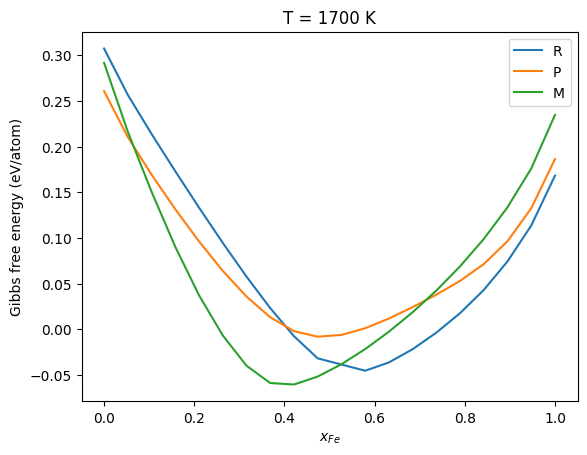

In [77]:
for T, dataT in DG.items():
    if len(dataT) == 0:
        continue
    fig, ax = plt.subplots()
    for phase, thedgs in dataT.items():
        if len(thedgs) == 0:
            continue
        ax.plot(thedgs.index, thedgs['DG'], label=phase)
    ax.legend()
    ax.set_xlabel('$x_{Fe}$')
    ax.set_ylabel('Gibbs free energy (eV/atom)')
    ax.set_title(f'T = {T} K')
    fig.show()

In [78]:
colors={
    '12': 'r',
    '14': 'b',
    '15': 'g',
    '16':  'k',
}

In [79]:
def get_line_color(CN: str):
    for cn, c in colors.items():
        if cn in CN:
            return c
    return 'grey'

In [80]:
#markers = ["1", "2", "3", "4",   0,   1,   2,   3,  4,  5,   6,   7,   8, 'd']
markers = ['>', 'v', '^', '>', 'p', 's', 'P', '*','D','X', 'd', 4, 5, 6]

/tmp/ipykernel_121045/1199634725.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
/tmp/ipykernel_121045/1199634725.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
/tmp/ipykernel_121045/1199634725.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)


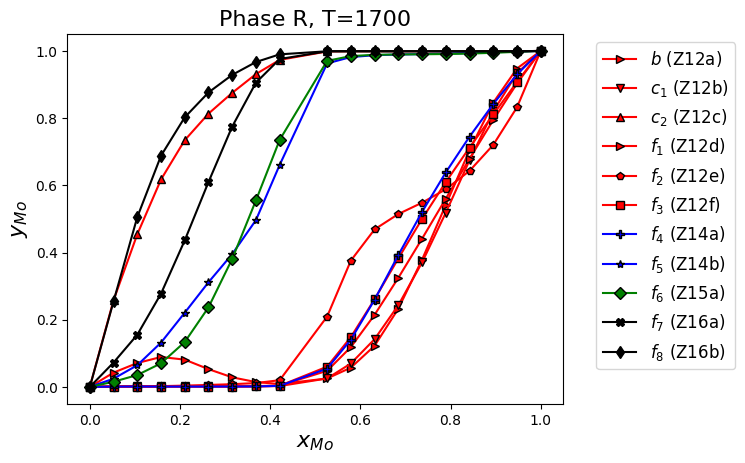

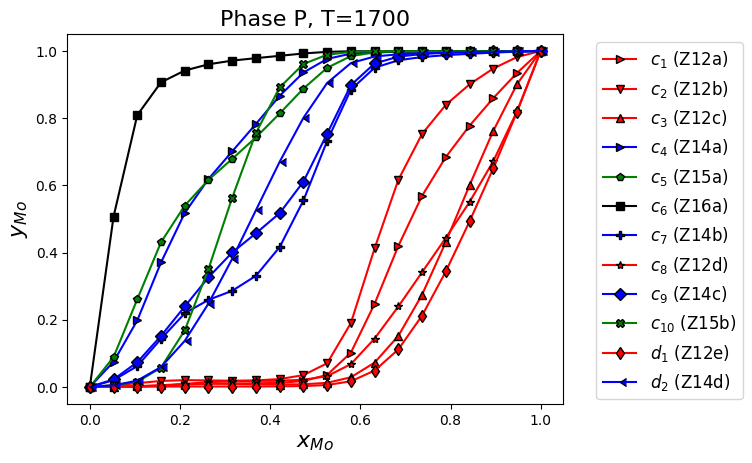

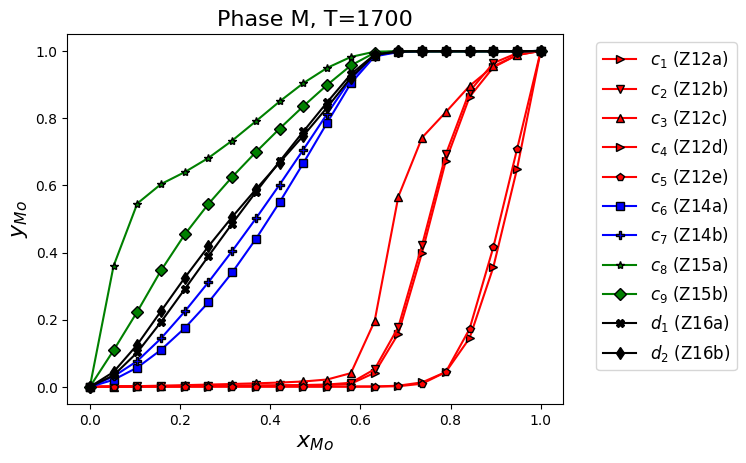

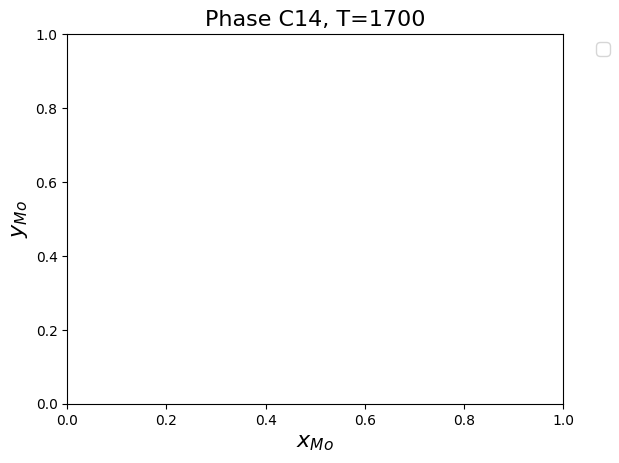

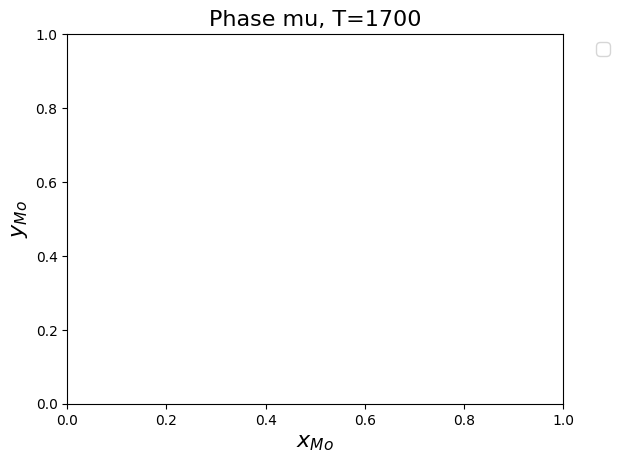

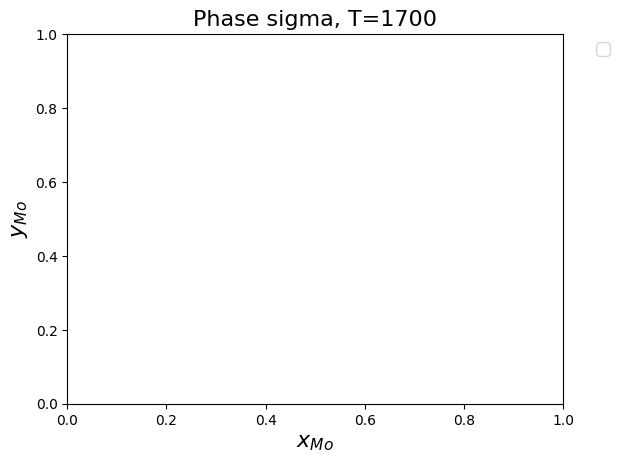

In [81]:
for T, phase_dg in DG.items():
    for phase, dg in phase_dg.items():
        sorted_uinique_cns, indexes = np.unique(cn_dict[phase], return_index=True)
        unique_cns = np.array(cn_dict[phase])[np.sort(indexes)]
        fig, ax = plt.subplots()
        for i, (colname, coldata) in enumerate( dg.filter(regex='A').items()):
            thisc = get_line_color(unique_cns[i])
            ax.plot(1-coldata.index, 1-coldata.values, marker = markers[i], color=thisc, label = f'{colname.replace("A@","")} ({unique_cns[i]})', markeredgecolor = 'k')
        ax.set_ylabel(f'$y_{{Mo}}$', fontsize=16)
        ax.set_xlabel(f'$x_{{Mo}}$', fontsize=16)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
        ax.set_title(f'Phase {phase}, T={T}', fontsize=16)

In [82]:
phase_dg.keys()

dict_keys(['R', 'P', 'M', 'C14', 'mu', 'sigma'])

# load experimental data

In [82]:
experimentaldata = pd.read_csv('Fe-Mo/ExperimentalData/CrWCo.csv', header=[0], index_col = 0)
experimental_cn = {  'D1': '16','D2':'16','C1':'15','B1':'14','B2':'14','A1':'12','A2':'12','A3':'12','A4':'12','A5':'12','A6':'12'}

In [83]:
experimentaldata.columns

Index(['D1', 'D2', 'C1', 'B1', 'B2', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6'], dtype='object')

In [84]:
experimentaldata_sites_rename={'D1': '$c_2$', 'D2': '$f_8$', 'C1': '$f_7$', 'B1': '$f_5$', 'B2': '$f_6$', 'A1': '$b$', 'A2': '$c_1$', 'A3': '$f_1$', 'A4': '$f_2$', 'A5': '$f_3$', 'A6':'$f_4$'}

In [85]:
experimentaldata.rename(columns=experimentaldata_sites_rename, inplace=True)

In [86]:
experimentaldata

,$c_2$,$f_8$,$f_7$,$f_5$,$f_6$,$b$,$c_1$,$f_1$,$f_2$,$f_3$,$f_4$
composition,,,,,,,,,,,
0.27958,1.00000,1.00000,0.46667,0.37849,0.32258,0.000000,0.000000,0.000000,0.000000,0,0
0.30968,1.00000,0.97204,0.50968,0.42151,0.45806,0.060215,0.049462,0.030108,0.017204,0,0
0.31958,1.00000,1.00000,0.55054,0.41935,0.41935,0.079570,0.079570,0.000000,0.000000,0,0
0.33465,0.93118,0.93118,0.64086,0.49892,0.50968,0.141940,0.040860,0.019355,0.004301,0,0
0.34988,1.00000,0.99570,0.69032,0.55054,0.51828,0.030108,0.019355,0.000000,0.000000,0,0
0.35485,0.99785,0.80860,0.76129,0.51183,0.62796,0.049462,0.040860,0.006452,0.000000,0,0
0.37978,0.99800,0.99800,0.75914,0.62366,0.52903,0.111830,0.107530,0.000000,0.000000,0,0


# compare experimental data to prediction

In [87]:
figw, figh = plt.rcParams['figure.figsize']

In [88]:
plt.rc('text', usetex=True)

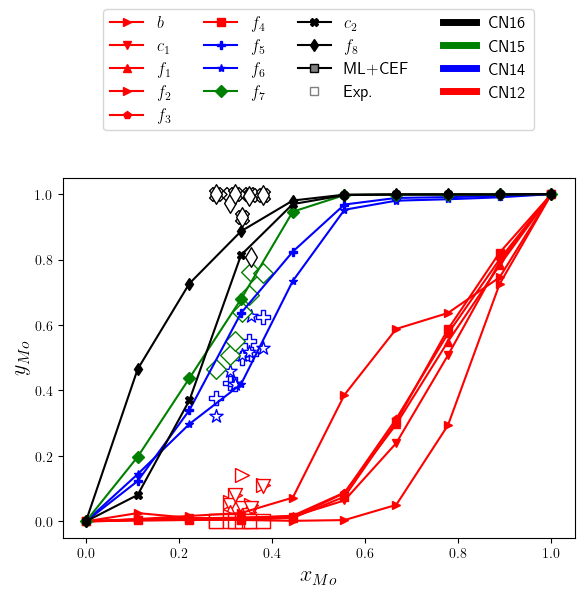

In [89]:
fig = plt.figure(figsize=(figw, 3*figh/2))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.5])
#for site, sitedata in experimentaldata.items():
#    ax.scatter(sitedata.index, sitedata.values, c=colors[experimental_cn[site]])
phase='R'
T=1700
dg=DG[T][phase]
sorted_uinique_cns, indexes = np.unique(cn_dict[phase], return_index=True)
unique_cns = np.array(cn_dict[phase])[np.sort(indexes)]
for i, (colname, coldata) in enumerate( dg.filter(regex='A').items()):
    thisc = get_line_color(unique_cns[i])
    ax.plot(1-coldata.index, 1-coldata.values, marker = markers[i], color=thisc, label = f'{colname.replace("A@","")}')#    ({unique_cns[i]})')
    ax.scatter(experimentaldata.index, experimentaldata[colname.replace('A@', '')], marker = markers[i], s = 100, facecolor='w', edgecolor=thisc, linewidth=1)
#for i, (colname, coldata) in enumerate( dgmix.filter(regex='A').items()):
#    thisc = get_line_color(unique_cns[i])
#    ax.plot(1-coldata.index, 1-coldata.values, linestyle = '--', color=thisc)#, label = f'{colname.replace("A@","")} ({unique_cns[i]})') # marker = markers[i],
handles, labels = ax.get_legend_handles_labels()
#handles.append(Line2D([],[],linestyle='--')),
handles.append(Line2D([],[],marker='s', markerfacecolor = 'grey', color = 'k'))
handles.append(Line2D([],[],marker='s', markerfacecolor = 'white', color='grey', linewidth=5, linestyle='',))
handles.append(Line2D([],[], linestyle='-', linewidth=5, color='k', label = 'CN16'))
handles.append(Line2D([],[], linestyle='-', linewidth=5, color='g', label = 'CN15'))
handles.append(Line2D([],[], linestyle='-', linewidth=5, color='b', label = 'CN14'))
handles.append(Line2D([],[], linestyle='-', linewidth=5, color='r', label = 'CN12'))

#labels.append('10 sublattice model')
labels.append('ML+CEF')
labels.append('Exp.')
labels.append('CN16')
labels.append('CN15')
labels.append('CN14')
labels.append('CN12')
ax.set_ylabel(f'$y_{{Mo}}$', fontsize=16)
ax.set_xlabel(f'$x_{{Mo}}$', fontsize=16)
ax.legend(handles, labels, bbox_to_anchor=(0.5, 1.3), loc='center', fontsize=12, ncols = 4)
#ax.legend(handles, labels, fontsize=12, ncols = 4)
# ax.set_title(f'Phase {phase}, T={T}', fontsize=16)
fig.savefig('Fe-Mo/graphs/SiteOccupancyExperimental_vs_Predictions.pdf')


In [56]:
labels

['$b$ (Z12a)',
 '$c_1$ (Z12b)',
 '$f_1$ (Z12c)',
 '$f_2$ (Z12d)',
 '$f_3$ (Z12e)',
 '$f_4$ (Z12f)',
 '$f_5$ (Z14a)',
 '$f_6$ (Z14b)',
 '$f_7$ (Z15a)',
 '$c_2$ (Z16a)',
 '$f_8$ (Z16b)',
 '10 sublattice model',
 'prediction from ML+CEF',
 'Experimental results']